# Tesla Deliveries Analysis and Forecasting
## Objective

The objective of this project is to build an end-to-end machine learning pipeline for analyzing Tesla delivery data. The project includes exploratory data analysis, feature engineering, preprocessing, regression modeling, hyperparameter tuning, and time-series forecasting to understand and predict vehicle deliveries.

## 1. Data Understanding

In this section, we examine the dataset structure, data types, descriptive statistics, and missing values to gain an initial understanding of the data.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
df.shape

(2640, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

## 2. Exploratory Data Analysis (EDA)

EDA is performed to identify patterns, relationships, and trends in the dataset. Visualizations are used to understand pricing, regional distributions, and feature correlations.

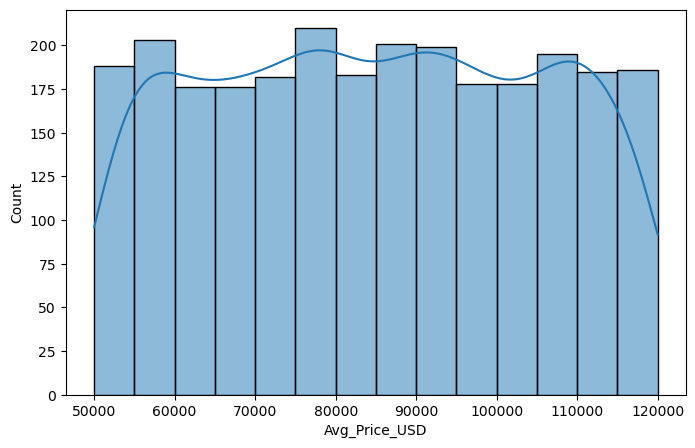

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Price_USD'], kde=True)
plt.show()

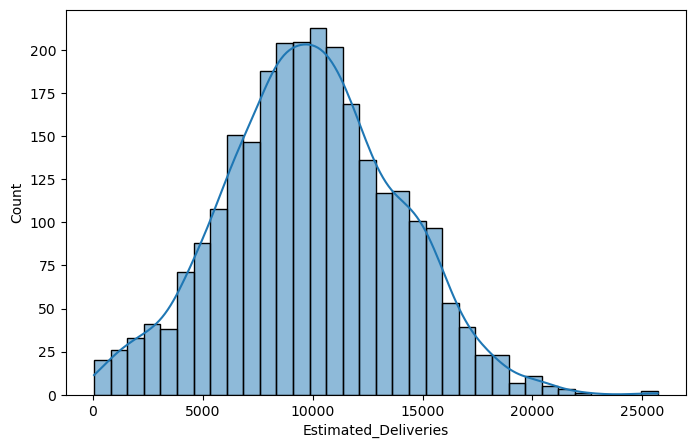

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.show()

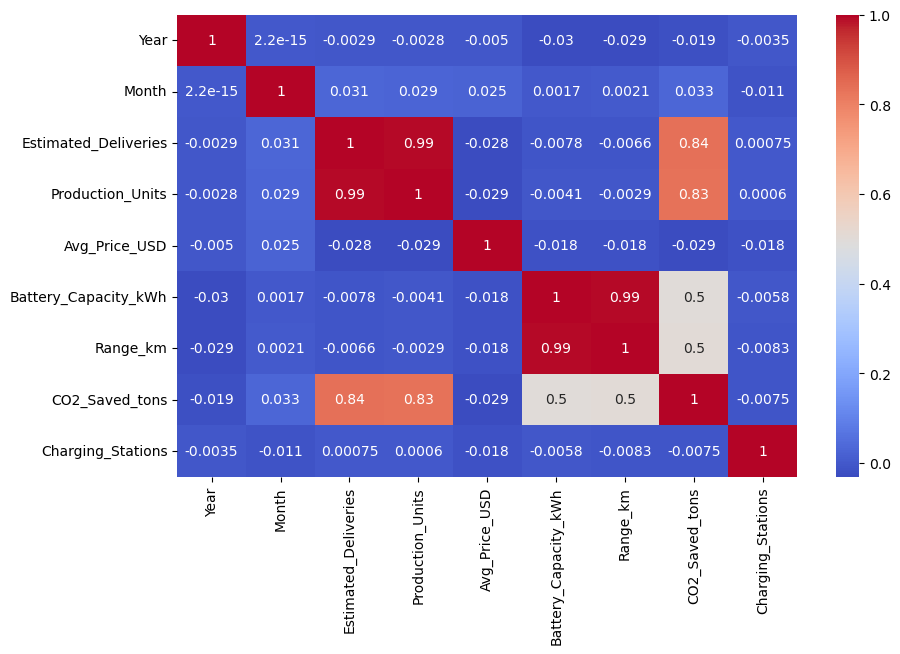

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

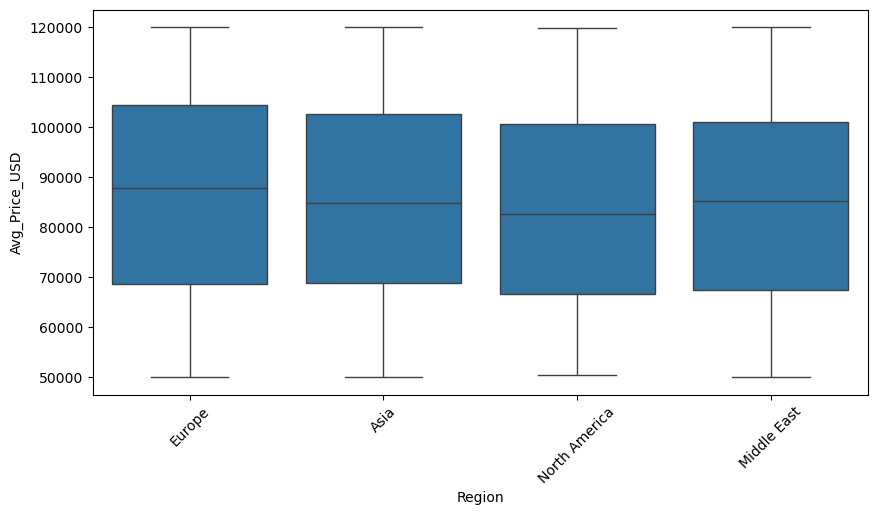

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Region',
    y='Avg_Price_USD',
    data=df
)

plt.xticks(rotation=45)
plt.show()

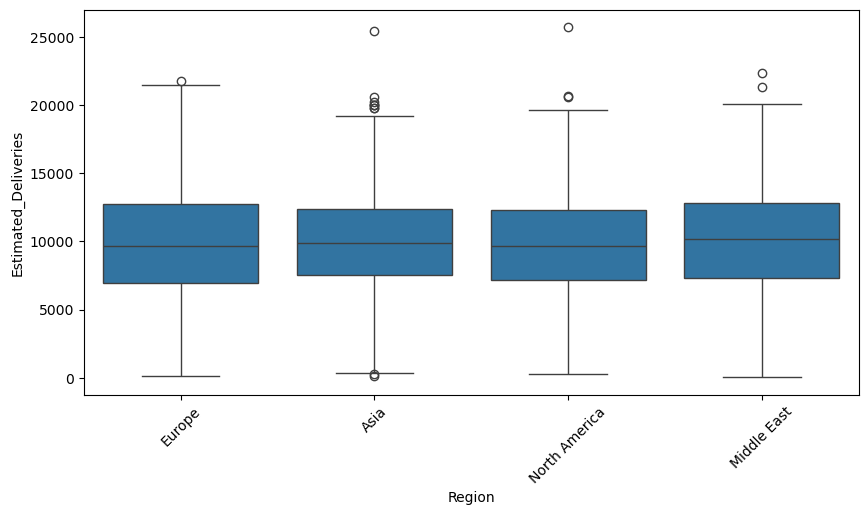

In [143]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.xticks(rotation=45)
plt.show()

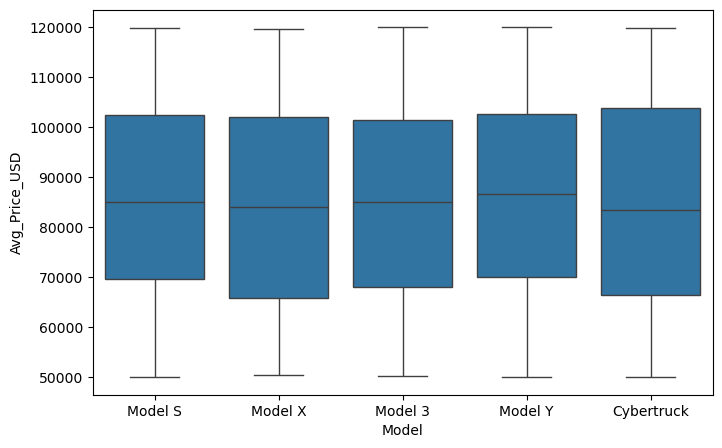

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Model',
    y='Avg_Price_USD',
    data=df
)

plt.show()

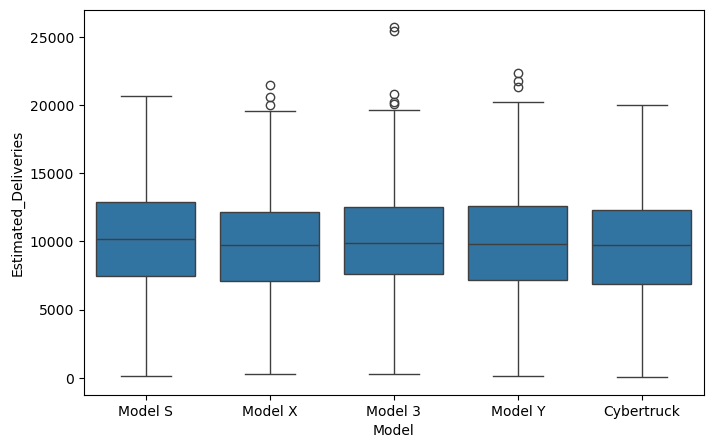

In [144]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)

plt.show()

## 3. Feature Engineering

Additional features are created to improve model performance and capture business-relevant information.

Features Created:

Date
Quarter
Month_Name
Efficiency
Production_Delivery_Ratio

In [10]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

In [11]:
df['Quarter'] = df['Date'].dt.quarter

In [12]:
df['Month_Name'] = df['Date'].dt.month_name()

In [13]:
df['Efficiency'] = (
    df['Range_km'] /
    df['Battery_Capacity_kWh']
)

In [14]:
df['Production_Delivery_Ratio'] = (
    df['Production_Units'] /
    df['Estimated_Deliveries']
)

## 4. Regression Modeling
Target Variable: Estimated_Deliveries

The objective is to predict vehicle deliveries using operational and production-related features.

Models Used:

Linear Regression
Decision Tree Regressor
Random Forest Regressor

In [108]:
target = 'Estimated_Deliveries'

In [109]:
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df['Estimated_Deliveries']

In [110]:
cat_cols = X.select_dtypes(
    include='object'
).columns.tolist()

num_cols = X.select_dtypes(
    exclude='object'
).columns.tolist()

In [111]:
corr = df.select_dtypes(include='number').corr()

print(
    corr['Estimated_Deliveries']
    .sort_values(ascending=False)
)

Estimated_Deliveries         1.000000
Production_Units             0.994234
CO2_Saved_tons               0.836814
Quarter                      0.035704
Month                        0.030877
Efficiency                   0.014403
Charging_Stations            0.000753
Production_Delivery_Ratio   -0.001135
Year                        -0.002863
Range_km                    -0.006606
Battery_Capacity_kWh        -0.007765
Avg_Price_USD               -0.027546
Name: Estimated_Deliveries, dtype: float64


In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
print(X.dtypes)

Year                           int64
Month                          int64
Region                        object
Model                         object
Production_Units               int64
Avg_Price_USD                float64
Battery_Capacity_kWh           int64
Range_km                       int64
CO2_Saved_tons               float64
Source_Type                   object
Charging_Stations              int64
Quarter                        int32
Month_Name                    object
Efficiency                   float64
Production_Delivery_Ratio    float64
dtype: object


In [114]:
cat_cols = X.select_dtypes(
    include='object'
).columns.tolist()

num_cols = X.select_dtypes(
    exclude='object'
).columns.tolist()

In [115]:
print(cat_cols)
print(num_cols)

['Region', 'Model', 'Source_Type', 'Month_Name']
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter', 'Efficiency', 'Production_Delivery_Ratio']


In [116]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [117]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [118]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [119]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression
MAE : 108.32413294204252
RMSE: 154.37642392208303
R2  : 0.9984012062527563


In [120]:
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

dt_preds = dt_pipeline.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_preds)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_r2 = r2_score(y_test, dt_preds)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2  :", dt_r2)

Decision Tree
MAE : 122.8219696969697
RMSE: 168.01818308886942
R2  : 0.9981061609976244


In [121]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest
MAE : 69.21045454545454
RMSE: 122.33689619584653
R2  : 0.9989959729721799


## 5. Model Evaluation

The models are evaluated using:

Mean Absolute Error (MAE)
Root Mean Squared Error (RMSE)
R² Score

The best-performing model is selected based on predictive performance.

In [122]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae
    ],

    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    'R2': [
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

results.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
2,Random Forest,69.210455,122.336896,0.998996
0,Linear Regression,108.324133,154.376424,0.998401
1,Decision Tree,122.821970,168.018183,0.998106


## 6. Hyperparameter Tuning

GridSearchCV is used to optimize the Random Forest Regressor and identify the best combination of parameters.

In [123]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    'model__n_estimators': [100, 200],

    'model__max_depth': [5, 10, 15],

    'model__min_samples_split': [2, 5]

}

In [124]:
grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.9981596344405264


## 7. Time Series Forecasting

Prophet is used to forecast future vehicle deliveries based on historical monthly delivery trends.

In [37]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 6.2 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/12.1 MB 3.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/12.1 MB 2.2 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/12.1 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/12.1 MB 1.8 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.1 MB 1.7 MB/s eta 0:00:06
   ------- -------------------------------- 2.4/12.1 MB 1.6 MB/s eta 0:00:07
   -------- ------------------------------- 2.6/12.1 MB 1.4 MB/s eta 0:00:07
   -------- ------------------------------- 2.6/12.1 MB 1.4 MB/s eta 0:00:07
   --------- ------------------------------ 2.9/12.1 MB 1.3 MB/s eta 0:00:08
   ---------- ----------------------------- 3.1/12.1 MB 1.3 MB/s eta 0:00:07
   ----------- ---------------------------- 3.4/12.1 MB 1.3 MB/s eta 0:00:07
   ---

In [134]:
ts = df.groupby(
    ['Year','Month']
)['Estimated_Deliveries'].sum().reset_index()

ts['Date'] = pd.to_datetime(
    ts['Year'].astype(str)
    + '-'
    + ts['Month'].astype(str)
)

ts = ts.sort_values('Date')

In [135]:
from prophet import Prophet

In [136]:
forecast_df = ts[['Date','Estimated_Deliveries']]

In [137]:
forecast_df.columns = [
    'ds',
    'y'
]

In [138]:
model = Prophet()

model.fit(forecast_df)

15:16:40 - cmdstanpy - INFO - Chain [1] start processing
15:16:41 - cmdstanpy - INFO - Chain [1] done processing


In [139]:
future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

F:\Anaconda\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [140]:
forecast = model.predict(
    future
)

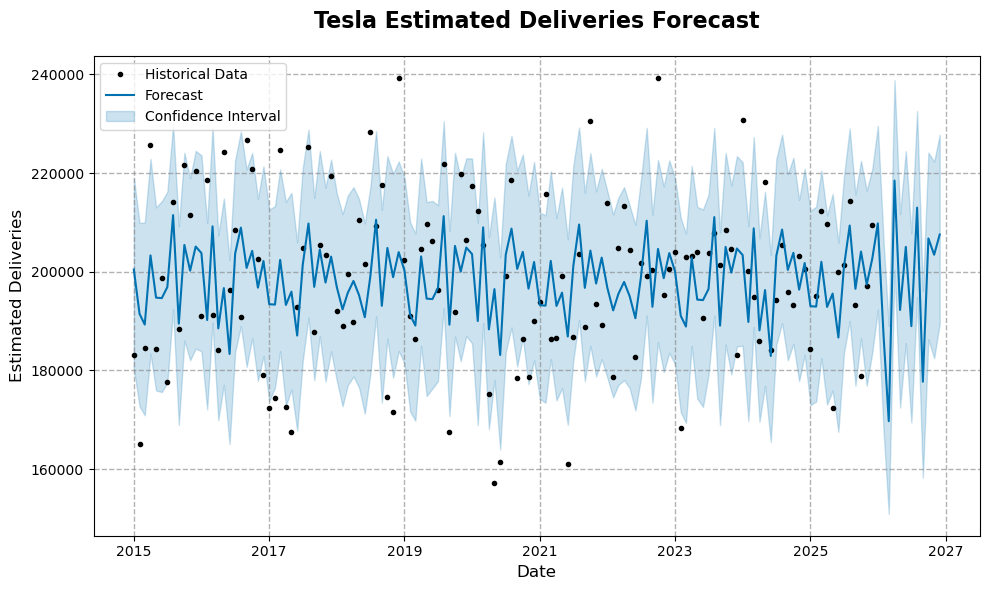

In [141]:
from prophet.plot import plot_plotly
import matplotlib.pyplot as plt

fig = model.plot(forecast)

ax = fig.gca()

ax.set_title('Tesla Estimated Deliveries Forecast',fontsize=16,fontweight='bold',pad=20)

ax.set_xlabel('Date',fontsize=12)

ax.set_ylabel('Estimated Deliveries',fontsize=12)

ax.grid(True, linestyle='--', alpha=0.6)

ax.legend(['Historical Data','Forecast','Confidence Interval'],loc='upper left')

plt.tight_layout()
plt.show()

Forecast Visualization

This visualization presents the forecasted Tesla vehicle deliveries generated using the Prophet time-series forecasting model. The solid line represents the predicted delivery trend, while the shaded region represents the uncertainty interval around the forecast. The graph helps identify future delivery patterns and expected growth trends based on historical data.

# Conclusion

This project implemented an end-to-end machine learning pipeline including EDA, feature engineering, preprocessing, regression modeling, hyperparameter tuning, and time-series forecasting.

Initially, Avg_Price_USD was considered as the target variable, but due to very weak correlations with the available features and negative R² scores, it was not used for the final model. Instead, Estimated_Deliveries was selected as the target variable.

Among the evaluated models, Random Forest Regressor achieved the best performance with an R² score of approximately 0.999. However, this exceptionally high score may indicate potential data leakage due to the strong relationship between Production_Units and Estimated_Deliveries.

Finally, Prophet was used to forecast future delivery trends, completing the forecasting component of the project.
